In [59]:
import numpy as np
import matplotlib as mpl
import matplotlib.pyplot as plt
import pickle

In [60]:
with open('ZdataAnalytic.pkl', 'rb') as f:
    Zanalytic = pickle.load(f)

with open('Zdata.pkl', 'rb') as f:
    Z = pickle.load(f)

with open('ZdataPred.pkl', 'rb') as f:
    dataPred = pickle.load(f)

with open('AppResdataAnalytic.pkl', 'rb') as f:
    appres = pickle.load(f)

with open('phasedataAnalytic.pkl', 'rb') as f:
    phase = pickle.load(f)

In [61]:
x_positions = [
    -5000, -2000, -1500, -1000, -750, -500, -400, -300, -250, -200,
    -150, -125, -100, -90, -80, -70, -60, -50, -40, -30,
    -20, -10, 0, 10, 20, 30, 40, 50, 60, 70,
    80, 90, 100, 125, 150, 200, 250, 300, 400, 500,
    750, 1000, 1500, 2000, 5000
]

y_positions = [
    -5000, -2000, -1500, -1000, -750, -500, -400, -300, -250, -200,
    -150, -125, -100, -90, -80, -70, -60, -50, -40, -30,
    -20, -10, 0, 10, 20, 30, 40, 50, 60, 70,
    80, 90, 100, 125, 150, 200, 250, 300, 400, 500,
    750, 1000, 1500, 2000, 5000
]

rx_locs = []

for x in x_positions:
    for y in y_positions:
        rx_locs.append([x, y, 0]) 

rx_locs = np.array(rx_locs)
print(rx_locs.shape)

(2025, 3)


In [62]:
dpred = dataPred
dp = dpred.reshape(71, 4, 2025)
np.set_printoptions(threshold=np.inf)
print(dp[30,0,990:1035].shape)

(45,)


In [63]:
print(Zanalytic[0, 23, 0, 0, 1])
print(Zanalytic[0, 23, 0, 1, 0])

(0.04653644360507389+0.046151596391048516j)
(-0.04653202353524429-0.04614845325264764j)


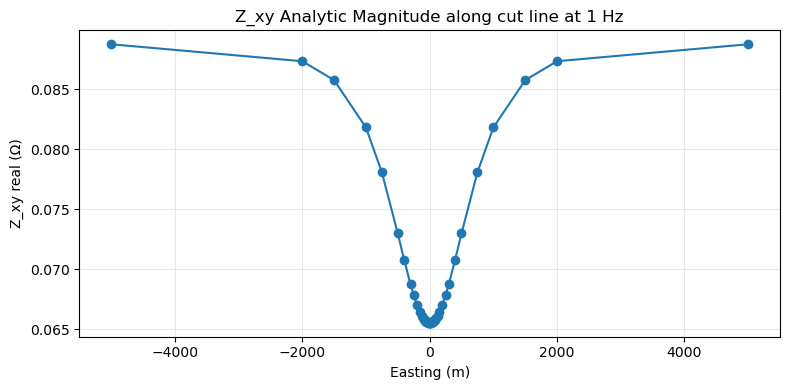

In [64]:
# Plot
fig, ax = plt.subplots(figsize=(8, 4))

x = np.array([
-5000,-2000,-1500,-1000,-750,-500,-400,-300,-250,-200,-150,-125,-100,-90,-80,-70,-60,-50,-40,-30,-20,-10,
0,10,20,30,40,50,60,70,80,90,100,125,150,200,250,300,400,500,750,1000,1500,2000,5000
])

ax.plot(x, abs(Zanalytic[0, :, 0, 1, 0]), 'o-')
ax.set_xlabel('Easting (m)')
ax.set_ylabel('Z_xy real (Ω)')
ax.set_title(f'Z_xy Analytic Magnitude along cut line at 1 Hz')
ax.grid(True, alpha=0.3)
plt.tight_layout()
plt.show()

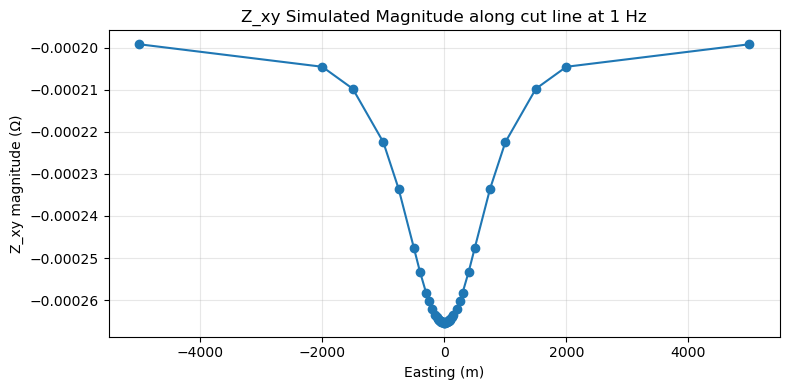

In [65]:
# Plot
fig, ax = plt.subplots(figsize=(8, 4))
ax.plot(x, dp[30, 1, 990:1035], 'o-')
ax.set_xlabel('Easting (m)')
ax.set_ylabel('Z_xy magnitude (Ω)')
ax.set_title(f'Z_xy Simulated Magnitude along cut line at 1 Hz')
ax.grid(True, alpha=0.3)
plt.tight_layout()
plt.show()

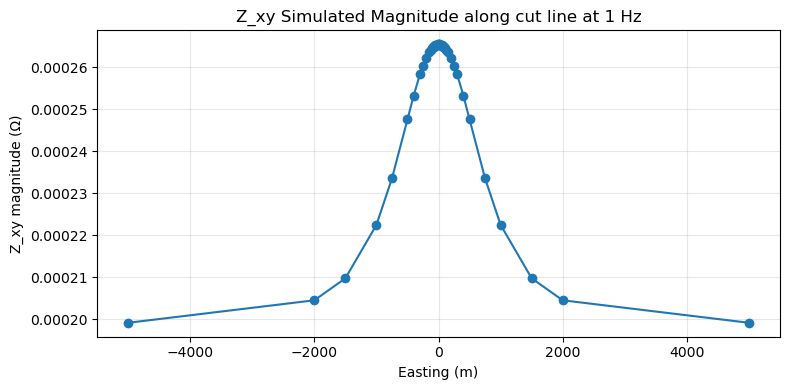

In [66]:
# Plot
fig, ax = plt.subplots(figsize=(8, 4))
ax.plot(x, np.sqrt(dp[30, 0, 990:1035]**2 + dp[30, 1, 990:1035]**2), 'o-')
ax.set_xlabel('Easting (m)')
ax.set_ylabel('Z_xy magnitude (Ω)')
ax.set_title(f'Z_xy Simulated Magnitude along cut line at 1 Hz')
ax.grid(True, alpha=0.3)
plt.tight_layout()
plt.show()

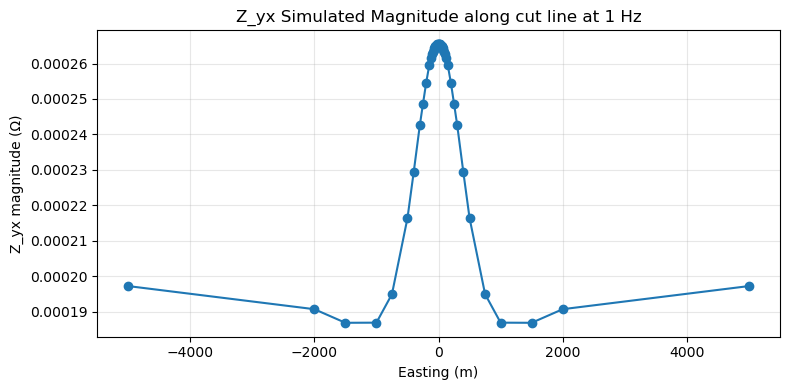

In [67]:
# Plot
fig, ax = plt.subplots(figsize=(8, 4))
ax.plot(x, np.sqrt(dp[30, 2, 990:1035]**2 + dp[30, 3, 990:1035]**2), 'o-')
ax.set_xlabel('Easting (m)')
ax.set_ylabel('Z_yx magnitude (Ω)')
ax.set_title(f'Z_yx Simulated Magnitude along cut line at 1 Hz')
ax.grid(True, alpha=0.3)
plt.tight_layout()
plt.show()

In [68]:
low_freq = 0.001
high_freq = 10000
samples_per_dec = 10

freqs = np.logspace(-3, 4, 10*7+1)

mu0 = 4 * np.pi * 1e-7
omega = 2 * np.pi * freqs[:, None]

Zxy = dp[:, 0, :] + 1j * dp[:, 1, :]
Zyx = dp[:, 2, :] + 1j * dp[:, 3, :]

# apparent resistivities
rho_xy = np.abs(Zxy)**2 / (mu0 * omega)
rho_yx = np.abs(Zyx)**2 / (mu0 * omega)

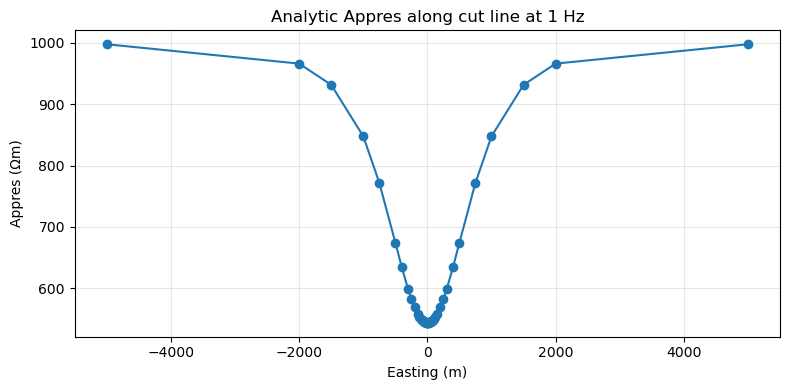

In [69]:
# Plot
fig, ax = plt.subplots(figsize=(8, 4))

ax.plot(x, appres[0, :, 0, 1, 0], 'o-')
ax.set_xlabel('Easting (m)')
ax.set_ylabel('Appres (Ωm)')
ax.set_title(f'Analytic Appres along cut line at 1 Hz')
ax.grid(True, alpha=0.3)
plt.tight_layout()
plt.show()

In [70]:
print(rho_xy.shape)

(71, 2025)


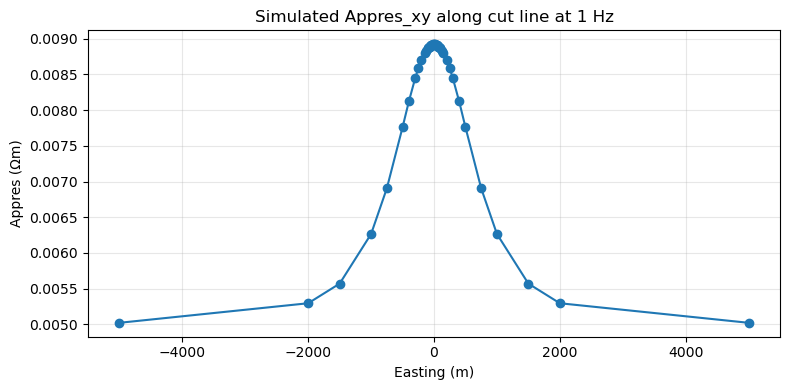

In [71]:
# Plot
fig, ax = plt.subplots(figsize=(8, 4))

ax.plot(x, rho_xy[30, 990:1035], 'o-')
ax.set_xlabel('Easting (m)')
ax.set_ylabel('Appres (Ωm)')
ax.set_title(f'Simulated Appres_xy along cut line at 1 Hz')
ax.grid(True, alpha=0.3)
plt.tight_layout()
plt.show()

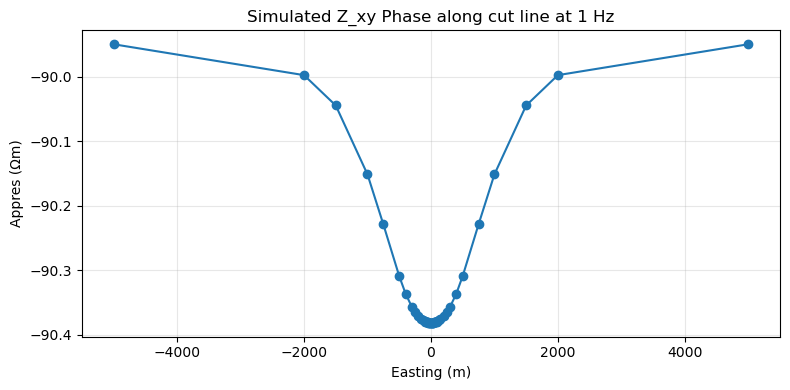

In [72]:
# Plot
fig, ax = plt.subplots(figsize=(8, 4))

ax.plot(x, np.degrees(np.angle(Zxy[30, 990:1035])), 'o-')
ax.set_xlabel('Easting (m)')
ax.set_ylabel('Appres (Ωm)')
ax.set_title(f'Simulated Z_xy Phase along cut line at 1 Hz')
ax.grid(True, alpha=0.3)
plt.tight_layout()
plt.show()